In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics opencv-python numpy pandas openpyxl easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 109.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 32.7 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 88.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="YourAPIKey")
project = rf.workspace("tamims-workspace-htvni").project("my-custom-data")
version = project.version(4)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to My-Custom-Data-4 in yolov8:: 100%|██████████| 7133/7133 [00:00<00:00, 8598.03it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
COLOR_DATASET_PATH = "/content/drive/MyDrive/vehicle_colors_dataset"
print(f"✅ Color dataset expected at: {COLOR_DATASET_PATH}")

✅ Color dataset expected at: /content/drive/MyDrive/vehicle_colors_dataset


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="YourAPIKey")
project = rf.workspace("tamims-workspace-htvni").project("number-plate-detection-pr-400-0fzwp")
version = project.version(2)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Number-Plate-Detection-pr-400-2 in yolov8:: 100%|██████████| 9403/9403 [00:00<00:00, 9867.75it/s] 


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os
from ultralytics import YOLO

# --- 1. Setup Drive Save Location ---
DRIVE_SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/YOLO_Models"
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

print(f"📂saved to: {DRIVE_SAVE_DIR}")

# --- 2. Load and Train ---
model = YOLO("yolo11n.pt")

model.train(
    data="/content/My-Custom-Data-4/data.yaml",
    epochs=300,        
    batch=64,          
    imgsz=640,
    patience=30,       
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    fliplr=0.0,
    flipud=0.0,
    mosaic=0.5,
    mixup=0.0,
    close_mosaic=10,
    workers=8,         
    device=0,
    project=DRIVE_SAVE_DIR,
    name="train_run_A100",
    save=True,
    save_period=5
)

📂 Models will be safely saved to: /content/drive/MyDrive/Colab Notebooks/YOLO_Models
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/My-Custom-Data-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c980fed1880>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [ ]:
from ultralytics import YOLO

print("🚀 Starting Training: Model 2 (Color Classification)...")

DRIVE_SAVE_DIR_COLOR = "/content/drive/MyDrive/Colab Notebooks/YOLO_Models"

# Load classification base model
color_model = YOLO("yolo11n-cls.pt")

# Train
color_model.train(
    data=COLOR_DATASET_PATH,
    epochs=100,            
    imgsz=224,
    batch=256,             
    patience=15,           
    workers=8,            
    project=DRIVE_SAVE_DIR_COLOR,
    name="color_classifier_A100",
    device=0
)
print(" Color classification model training complete!")

🚀 Starting Training: Model 2 (Color Classification)...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=256, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/vehicle_colors_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=color_classifie

In [ ]:
from ultralytics import YOLO

DRIVE_SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/YOLO_Models"



model = YOLO("yolo11n.pt")

print("⚡ Starting YOLOv11 Training")


results = model.train(
    data="/content/Number-Plate-Detection-pr-400-2/data.yaml", 
    epochs=100,                           
    imgsz=640,                            
    batch=64,                             
    device=0,                             
    project=DRIVE_SAVE_DIR,               
    name="char_model_A100",               
    exist_ok=True,                        
    patience=20                           
)

print(f" Training Complete! Your best weights are saved at: {DRIVE_SAVE_DIR}/char_model_A100/weights/best.pt")

⚡ Starting YOLOv11 Training
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Number-Plate-Detection-pr-400-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=char_model_A100, nbs=64, nms=False, opset=N

In [ ]:
import cv2
import numpy as np
import pandas as pd
import torch
import easyocr
import os

from ultralytics import YOLO
from google.colab import files
from datetime import datetime
from difflib import SequenceMatcher


DETECT_MODEL_PATH="/content/drive/MyDrive/Colab Notebooks/YOLO_Models/train_run_A100/weights/best.pt"
COLOR_MODEL_PATH="/content/drive/MyDrive/Colab Notebooks/YOLO_Models/color_classifier_A100/weights/best.pt"

VIDEO_PATH="/content/License Plate Detection Test(1080P_HD).mp4"

OUTPUT_VIDEO="processed_output.mp4"
EXCEL_FILE="registered_vehicles.xlsx"

DETECT_CONF=.15
LOG_CONF=.35
OCR_CONF=.45

MIN_PLATE_LEN=3
FUZZY_THRESHOLD=.85

PROCESS_EVERY_N=1

MIN_PLATE_H=10
MIN_PLATE_W=35

VEHICLE_CLASSES={
    "bike",
    "bus",
    "car",
    "truck",
    "cng"
}

DEVICE="cuda" if torch.cuda.is_available() else "cpu"
USE_GPU=torch.cuda.is_available()


print("Loading models...")

detect_model=YOLO(
    DETECT_MODEL_PATH
)

color_model=YOLO(
    COLOR_MODEL_PATH
)

ocr_engine=easyocr.Reader(
    ['en'],
    gpu=USE_GPU
)

print("Done")



def sharpen(img):

    kernel=np.array(
        [[0,-1,0],
         [-1,5,-1],
         [0,-1,0]]
    )

    return cv2.filter2D(
        img,
        -1,
        kernel
    )


def normalize_plate(txt):

    txt=txt.replace(
        " ",""
    )

    txt=txt.replace(
        "-",""
    )

    txt=txt.replace(
        "_",""
    )

    return "".join(
        c
        for c in txt
        if c.isalnum()
    ).upper()


def valid_plate(txt):

    if len(txt)<MIN_PLATE_LEN:
        return False

    count=sum(
        c.isalnum()
        for c in txt
    )

    return count>=2


def duplicate(new,seen):

    return any(

        SequenceMatcher(
            None,
            new,
            x
        ).ratio()

        >=FUZZY_THRESHOLD

        for x in seen
    )


def preprocess_plate(crop):

    if crop is None:
        return None

    if crop.size==0:
        return None

    h,w=crop.shape[:2]

    if h<MIN_PLATE_H:
        return None

    if w<MIN_PLATE_W:
        return None


    scale=128/h

    crop=cv2.resize(
        crop,
        None,
        fx=scale,
        fy=scale,
        interpolation=cv2.INTER_LANCZOS4
    )

    crop=cv2.copyMakeBorder(
        crop,
        15,
        15,
        15,
        15,
        cv2.BORDER_CONSTANT,
        value=[255,255,255]
    )

    gray=cv2.cvtColor(
        crop,
        cv2.COLOR_BGR2GRAY
    )

    den=cv2.fastNlMeansDenoising(
        gray,
        h=10
    )

    enh=cv2.createCLAHE(
        clipLimit=3,
        tileGridSize=(4,4)
    ).apply(den)

    _,binary=cv2.threshold(
        enh,
        0,
        255,
        cv2.THRESH_BINARY+cv2.THRESH_OTSU
    )

    return [

        crop,

        cv2.cvtColor(
            enh,
            cv2.COLOR_GRAY2BGR
        ),

        cv2.cvtColor(
            binary,
            cv2.COLOR_GRAY2BGR
        )

    ]


def run_ocr(crop):

    versions=preprocess_plate(
        crop
    )

    if versions is None:

        return "No Plate",0


    best_text="No Plate"
    best_conf=0


    for img in versions:

        try:

            result=ocr_engine.readtext(
                img
            )

            if len(result)==0:
                continue

            texts=[
                x[1]
                for x in result
            ]

            confs=[
                x[2]
                for x in result
            ]

            text="".join(
                texts
            )

            text=normalize_plate(
                text
            )

            conf=np.mean(
                confs
            )

            if valid_plate(
                text
            ):

                if conf>best_conf:

                    best_conf=conf
                    best_text=text

        except:

            continue


    return best_text,best_conf


def overlap(vehicle,plate):

    vx1,vy1,vx2,vy2=vehicle
    px1,py1,px2,py2=plate

    ox=max(
        0,
        min(vx2,px2)-max(vx1,px1)
    )

    oy=max(
        0,
        min(vy2,py2)-max(vy1,py1)
    )

    return ox*oy


cap=cv2.VideoCapture(
    VIDEO_PATH
)

w=int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)

h=int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)

fps=cap.get(
    cv2.CAP_PROP_FPS
)

writer=cv2.VideoWriter(

    OUTPUT_VIDEO,
    cv2.VideoWriter_fourcc(
        *"mp4v"
    ),
    fps,
    (w,h)

)

seen_plates=set()
plate_votes={}
registration=[]

frame_count=0

print("Processing...")


while cap.isOpened():

    ok,frame=cap.read()

    if not ok:
        break

    frame_count+=1


    if frame_count%PROCESS_EVERY_N!=0:

        writer.write(frame)
        continue


    frame=sharpen(frame)

    result=detect_model.track(

        frame,
        persist=True,
        tracker="botsort.yaml",
        conf=DETECT_CONF,
        imgsz=1280,
        augment=True,
        verbose=False

    )[0]


    vehicles=[]
    plates=[]


    if result.boxes is not None:

        for box in result.boxes:

            cls_id=int(
                box.cls[0]
            )

            name=detect_model.names[
                cls_id
            ]

            coords=tuple(
                map(
                    int,
                    box.xyxy[0]
                )
            )

            conf=float(
                box.conf[0]
            )

            tid=-1

            if box.id is not None:

                tid=int(
                    box.id[0]
                )

            if name in VEHICLE_CLASSES:

                vehicles.append({

                    "type":name,
                    "coords":coords,
                    "id":tid,
                    "conf":conf

                })

            elif name=="License_Plate":

                plates.append({

                    "coords":coords

                })


    for v in vehicles:

        tid=v["id"]

        if tid==-1:
            continue

        vx1,vy1,vx2,vy2=v["coords"]


        best=None
        area=0


        for p in plates:

            a=overlap(

                v["coords"],
                p["coords"]

            )

            if a>area:

                area=a
                best=p


        text="No Plate"
        ocr_conf=0


        if best:

            px1,py1,px2,py2=best["coords"]

            crop=frame[
                py1:py2,
                px1:px2
            ]

            text,ocr_conf=run_ocr(
                crop
            )


        if tid not in plate_votes:

            plate_votes[
                tid
            ]=[]


        if text!="No Plate":

            plate_votes[
                tid
            ].append(
                (text,ocr_conf)
            )


        plate_votes[
            tid
        ]=plate_votes[
            tid
        ][-10:]


        final_text="No Plate"
        final_conf=0


        if len(
            plate_votes[tid]
        )>0:

            texts=[
                x[0]
                for x in plate_votes[
                    tid
                ]
            ]

            final_text=max(
                set(texts),
                key=texts.count
            )

            vals=[

                x[1]

                for x in plate_votes[
                    tid
                ]

                if x[0]==final_text
            ]

            final_conf=np.mean(
                vals
            )


        color="Unknown"

        try:

            vehicle_crop=frame[
                vy1:vy2,
                vx1:vx2
            ]

            if vehicle_crop.size>0:

                cres=color_model(
                    vehicle_crop,
                    verbose=False
                )[0]

                color=color_model.names[
                    cres.probs.top1
                ]

        except:
            pass


        label=(
            f"ID:{tid} "
            f"{color} "
            f"{v['type']} "
            f"{final_text}"
        )


        cv2.rectangle(

            frame,
            (vx1,vy1),
            (vx2,vy2),
            (0,255,0),
            2

        )


        cv2.putText(

            frame,
            label,
            (vx1,vy1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            .6,
            (0,255,0),
            2

        )


        if (

            final_text!="No Plate"
            and final_conf>=OCR_CONF
            and len(
                plate_votes[tid]
            )>=5
            and not duplicate(
                final_text,
                seen_plates
            )

        ):

            registration.append({

                "Timestamp":
                datetime.now().strftime(
                    "%Y-%m-%d %H:%M:%S"
                ),

                "Track_ID":tid,
                "Color":color,
                "Type":v["type"],
                "Plate_Number":final_text,
                "OCR_Conf":round(
                    final_conf,
                    3
                )

            })

            seen_plates.add(
                final_text
            )

            print(
                f"Logged: {final_text}"
            )


    writer.write(
        frame
    )


cap.release()
writer.release()


if len(registration)>0:

    df=pd.DataFrame(
        registration
    )

    df.to_excel(
        EXCEL_FILE,
        index=False
    )

    files.download(
        EXCEL_FILE
    )


files.download(
    OUTPUT_VIDEO
)

print("Done")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading models...


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteDone
Processing...
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 305ms
Prepared 1 package in 55ms
Installed 1 package in 3ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Logged: MSSU
Logged: GXIS0GJ
Logged: GXISOCJ
Logged: VU5Z
Logged: EEINBG
Logged: EGINBG
Logged: EYSINBG
Logged: HHL
Logged: EYGINAG
Logged: BG6SUSJ
Logged: NSAKGJ
Logged: E610DZT
Logged: 234
Logged: EFODZT
Logged: BLUT
Logged: KHO6KSU
Logged: KHOERSU
Logged: GJOBZED
Logged: LNISZZC
Logged: 0O7CL
Logged: DAOZCL
Logged: DOZCLX
Logged: MPA
Logged: DNA
Logged: DAOZLLX
Logged: 172
Logged: MNA
Logged: KBY
Logged: BPELMH
Logged: LUP
Logged: 1G6SZFX
Logged: T6BZEX
Logged: 65ZEX
Logged: 0G65ZFX
Logged: LFO
Logged: LFL
Logged: LPL
Logged: LPLLL
Logge

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done


In [ ]:
import cv2
import numpy as np
import pandas as pd
from ultralytics import YOLO
from google.colab import files
from datetime import datetime
from collections import defaultdict



DETECT_MODEL_PATH="/content/drive/MyDrive/Colab Notebooks/YOLO_Models/train_run_A100/weights/best.pt"
COLOR_MODEL_PATH="/content/drive/MyDrive/Colab Notebooks/YOLO_Models/color_classifier_A100/weights/best.pt"
CHAR_MODEL_PATH="/content/drive/MyDrive/Colab Notebooks/YOLO_Models/char_model_A100/weights/best.pt"

VIDEO_PATH="/content/HnVideoEditor_2026_05_18_214828341.mp4"

OUTPUT_VIDEO="output_final.mp4"
EXCEL_FILE="vehicle_log.xlsx"

DETECT_CONF=.25
CHAR_CONF=.25

PROCESS_EVERY_N=1

DETECT_IMGSZ=1280
CHAR_IMGSZ=640

MIN_PLATE_LEN=4
MIN_SCORE=.50

VOTE_HISTORY=10
MIN_VOTES=5

VEHICLE_CLASSES={
    'bike',
    'bus',
    'car',
    'truck',
    'cng'
}



print("Loading models...")

detect_model=YOLO(DETECT_MODEL_PATH)
color_model=YOLO(COLOR_MODEL_PATH)
char_model=YOLO(CHAR_MODEL_PATH)

print("Models loaded.")


BANGLA_MAP={

'Dhaka':'ঢাকা',
'Metro':'মেট্রো',

'Ka':'ক',
'Kha':'খ',
'Ga':'গ',
'Gha':'ঘ',
'Cha':'চ',
'Chha':'ছ',
'Ja':'জ',
'Jha':'ঝ',
'Ta':'ট',
'Tha':'ঠ',
'Da':'ড',
'Dha':'ঢ',
'Na':'ন',
'Pa':'প',
'Pha':'ফ',
'Ba':'ব',
'Bha':'ভ',
'Ma':'ম',
'Ya':'য',
'Ra':'র',
'La':'ল',
'Sha':'শ',
'Sa':'স',
'Ha':'হ',

'0':'০',
'1':'১',
'2':'২',
'3':'৩',
'4':'৪',
'5':'৫',
'6':'৬',
'7':'৭',
'8':'৮',
'9':'৯'

}

BANGLA_DIGITS="০১২৩৪৫৬৭৮৯"

BANGLA_LETTERS={

'ক','খ','গ','ঘ',
'চ','ছ','জ','ঝ',
'ট','ঠ','ড','ঢ',
'ন','প','ফ','ব',
'ভ','ম','য','র',
'ল','শ','স','হ'

}


def preprocess_plate(img):

    gray=cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    gray=cv2.fastNlMeansDenoising(
        gray,
        h=10
    )

    gray=cv2.createCLAHE(
        clipLimit=3,
        tileGridSize=(4,4)
    ).apply(gray)

    kernel=np.array(

        [[0,-1,0],
         [-1,5,-1],
         [0,-1,0]]

    )

    gray=cv2.filter2D(
        gray,
        -1,
        kernel
    )

    return cv2.cvtColor(
        gray,
        cv2.COLOR_GRAY2BGR
    )


def assign_plate(
    vehicle_box,
    plates
):

    vx1,vy1,vx2,vy2=vehicle_box

    best=None
    best_score=0

    for p in plates:

        px1,py1,px2,py2=p["coords"]

        pcx=(px1+px2)/2
        pcy=(py1+py2)/2

        # plate center must be inside vehicle

        if not (

            vx1<pcx<vx2 and
            vy1<pcy<vy2

        ):

            continue


        vehicle_area=(
            (vx2-vx1)*
            (vy2-vy1)
        )

        plate_area=(
            (px2-px1)*
            (py2-py1)
        )

        ratio=plate_area/vehicle_area

        if ratio<0.002:
            continue

        if ratio>.15:
            continue


        relative_y=(
            pcy-vy1
        )/(vy2-vy1)

        if relative_y<0.35:
            continue


        if ratio>best_score:

            best_score=ratio
            best=p

    return best


def plate_quality(
    text,
    conf
):

    score=conf

    score+=len(text)*0.02

    parts=text.split()

    if len(parts)>=4:
        score+=0.40

    if any(
        x in text
        for x in BANGLA_LETTERS
    ):
        score+=0.20

    digit_count=sum(

        c in BANGLA_DIGITS
        for c in text

    )

    score+=digit_count*.03

    return score


def read_plate(
    boxes,
    names,
    h
):

    if len(boxes)==0:

        return "No Plate",0


    top=[]
    bottom=[]
    scores=[]

    middle=h/2


    for b in boxes:

        x1,y1,x2,y2=map(
            int,
            b.xyxy[0]
        )

        cls=int(
            b.cls[0]
        )

        conf=float(
            b.conf[0]
        )

        char=BANGLA_MAP.get(

            names[cls],
            names[cls]

        )

        cx=(x1+x2)/2
        cy=(y1+y2)/2

        if cy<middle:

            top.append(
                (cx,char)
            )

        else:

            bottom.append(
                (cx,char)
            )

        scores.append(conf)


    top=sorted(top)
    bottom=sorted(bottom)

    top_text=' '.join(
        x[1]
        for x in top
    )

    bottom_text=''.join(
        x[1]
        for x in bottom
    )

    text=(

        top_text+
        " "+
        bottom_text

    ).strip()

    return text,np.mean(scores)



history=defaultdict(list)
database={}
seen_plates=set()


cap=cv2.VideoCapture(VIDEO_PATH)

fps=cap.get(
    cv2.CAP_PROP_FPS
)

w=int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)

h=int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)

writer=cv2.VideoWriter(

    OUTPUT_VIDEO,

    cv2.VideoWriter_fourcc(
        *'mp4v'
    ),

    fps,
    (w,h)

)

frame_count=0


while cap.isOpened():

    ok,frame=cap.read()

    if not ok:
        break


    frame_count+=1

    if frame_count%PROCESS_EVERY_N:

        writer.write(
            frame
        )

        continue


    results=detect_model.track(

        frame,

        persist=True,

        tracker="botsort.yaml",

        conf=DETECT_CONF,

        imgsz=DETECT_IMGSZ,

        verbose=False

    )[0]


    vehicles=[]
    plates=[]


    if results.boxes is not None:

        for box in results.boxes:

            cls=detect_model.names[
                int(
                    box.cls[0]
                )
            ]

            coords=tuple(
                map(
                    int,
                    box.xyxy[0]
                )
            )

            tid=-1

            if box.id is not None:

                tid=int(
                    box.id[0]
                )

            if cls in VEHICLE_CLASSES:

                vehicles.append({

                    "coords":coords,
                    "track":tid,
                    "type":cls

                })

            elif cls=="License_Plate":

                plates.append({

                    "coords":coords

                })



    for v in vehicles:

        vx1,vy1,vx2,vy2=v["coords"]

        tid=v["track"]

        if tid==-1:
            continue


        matched=assign_plate(
            v["coords"],
            plates
        )

        plate="No Plate"
        conf=0


        if matched:

            px1,py1,px2,py2=matched["coords"]

            crop=frame[
                py1:py2,
                px1:px2
            ]

            if crop.size>0:

                target=192

                scale=target/crop.shape[0]

                crop=cv2.resize(

                    crop,
                    None,
                    fx=scale,
                    fy=scale,

                    interpolation=cv2.INTER_CUBIC
                )

                crop=preprocess_plate(
                    crop
                )

                chars=char_model(

                    crop,

                    imgsz=CHAR_IMGSZ,

                    conf=CHAR_CONF,

                    iou=.30,

                    verbose=False

                )[0]

                plate,conf=read_plate(

                    chars.boxes,
                    char_model.names,
                    crop.shape[0]

                )


        color="Unknown"

        vehicle_crop=frame[
            vy1:vy2,
            vx1:vx2
        ]

        if vehicle_crop.size>0:

            c=color_model(
                vehicle_crop,
                verbose=False
            )[0]

            color=color_model.names[
                c.probs.top1
            ]


        if plate!="No Plate":

            history[tid].append(
                (plate,conf)
            )

        history[tid]=history[tid][-VOTE_HISTORY:]


        if len(history[tid])>=MIN_VOTES:

            candidates={}

            for p,s in history[tid]:

                q=plate_quality(
                    p,
                    s
                )

                if p not in candidates:
                    candidates[p]=[]

                candidates[p].append(q)


            final=max(

                candidates,

                key=lambda x:
                np.mean(
                    candidates[x]
                )

            )

            final_score=np.mean(
                candidates[final]
            )

            if (

                final not in seen_plates
                and len(final)>=MIN_PLATE_LEN
                and final_score>=MIN_SCORE

            ):

                database[tid]={

                    "Time":
                    datetime.now().strftime(
                        "%H:%M:%S"
                    ),

                    "ID":tid,
                    "Color":color,
                    "Type":v["type"],
                    "Plate":final,
                    "Score":round(
                        final_score,
                        3
                    )
                }

                seen_plates.add(
                    final
                )

                print(
                    f"Logged: {color} {v['type']} | {final} ({final_score:.2f})"
                )


        cv2.rectangle(
            frame,
            (vx1,vy1),
            (vx2,vy2),
            (0,255,0),
            2
        )

        cv2.putText(

            frame,

            f"{color} {v['type']}",

            (vx1,vy1-10),

            cv2.FONT_HERSHEY_SIMPLEX,
            .6,
            (0,255,0),
            2
        )


    writer.write(frame)



cap.release()
writer.release()

if database:

    df=pd.DataFrame(
        list(
            database.values()
        )
    )

    df.to_excel(
        EXCEL_FILE,
        index=False
    )

    files.download(
        EXCEL_FILE
    )

files.download(
    OUTPUT_VIDEO
)

print("Finished")

Loading models...
Models loaded.
Logged: grey truck | ০০০০০১ (0.79)
Logged: grey truck | ১১০০১ (0.86)
Logged: grey truck | ৭ ১৭ (0.54)
Logged: grey truck | ৫ ১৭ (0.64)
Logged: grey truck | Narayanganj ৭৭ (0.85)
Logged: grey truck | Narayanganj ৭৭৫ (0.86)
Logged: beige truck | ৩৭১১৫১৭০ (0.88)
Logged: yellow truck | ৭১৭৫২১ (0.80)
Logged: yellow truck | Chatto ২৫০ (0.79)
Logged: yellow truck | Chatto Chatto ট ১১১১ (1.66)
Logged: yellow truck | ঢাকা ঢাকা ১১১০১১৩ (1.37)
Logged: yellow truck | ঢাকা Chatto ঢাকা ১১১৩৩ (1.77)
Logged: grey truck | ঢাকা ১১০১৩৩ (1.20)
Logged: yellow truck | ঢাকা মেট্রো ঘ ১০২০ (1.67)
Logged: grey truck | মেট্রো গ ২১১১১০৩ (1.30)
Logged: yellow truck | ঢাকা মেট্রো ট ১০১০৩ (1.74)
Logged: yellow truck | ঢাকা মেট্রো ট ২১৩১১০৩ (1.86)
Logged: yellow truck | ঢাকা মেট্রো ট ১৩৫২১০৩ (1.75)
Logged: yellow truck | ঢাকা মেট্রো ১৩০৮০০ (1.40)
Logged: yellow truck | ঢাকা মেট্রো ১৩০৮০৭৪ (1.44)
Logged: yellow truck | ঢাকা মেট্রো ঢাকা ১৩০২৮০ (1.87)
Logged: yellow truck | ঢাকা মেট্রো ১

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Finished


**IMAGE TESTING BANGLA**

---



⏳ Loading 3 YOLO Models for Image Debugging...
✅ Models Loaded!
📸 Processing Image: /content/ing-2.png (1918x981)
🔍 Found 1 vehicle(s) and 1 license plate(s).

--- 🛠️ AI MODEL DIAGNOSTICS ---
Vehicle Type  : truck
Vehicle Color : yellow
Final OCR Text: ঢাকা মেট্রো ট ১৩০৮০৩
Avg OCR Conf  : 0.822
Valid Check   : PASS
-------------------------------

💾 Visual debug dashboard saved to: debug_output_final.jpg
✨ Rendering Final Calibration Image:


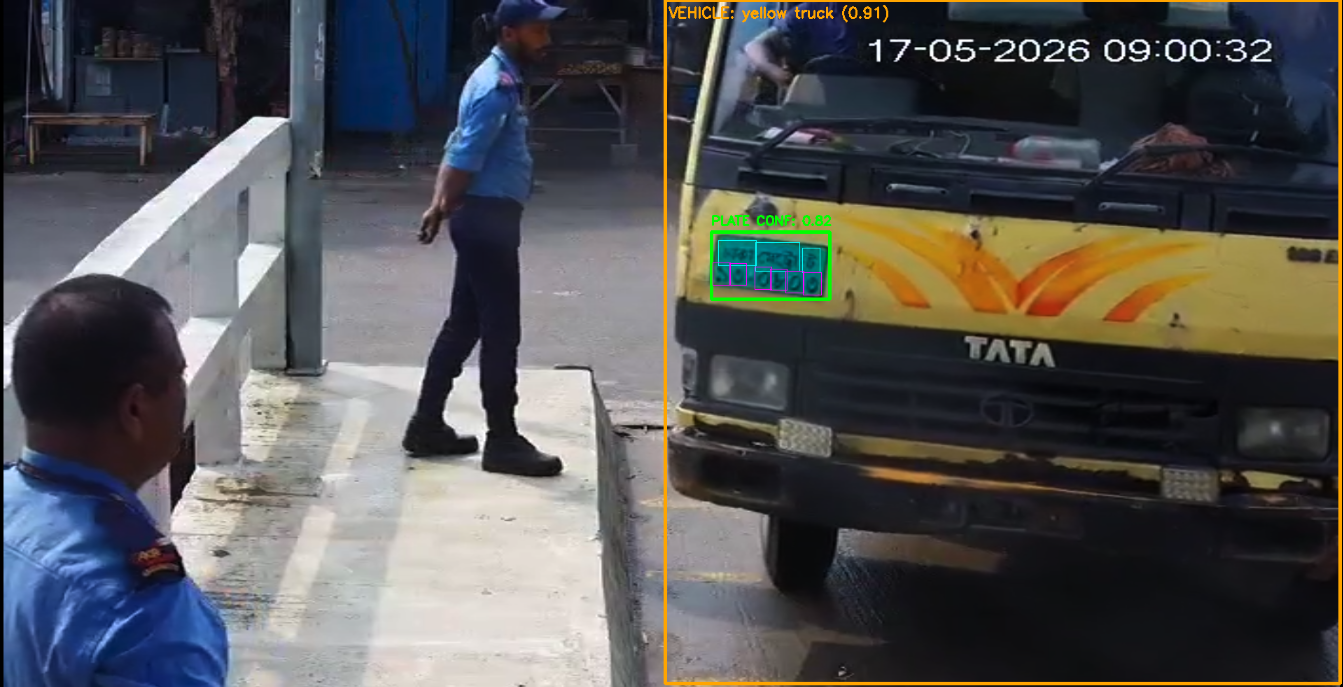

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import numpy as np
import os
from ultralytics import YOLO
from google.colab import files



DETECT_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/YOLO_Models/train_run_A100/weights/best.pt"
COLOR_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/YOLO_Models/color_classifier_A100/weights/best.pt"
CHAR_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/YOLO_Models/char_model_A100/weights/best.pt"

IMAGE_PATH = "/content/img-7.png"
OUTPUT_IMAGE = "debug_output_final.jpg"

DETECT_CONF = 0.15
CHAR_CONF = 0.50
CHAR_IOU = 0.30

MIN_PLATE_LEN = 4
MIN_SCORE = 0.50

VEHICLE_CLASSES = {
    "bike",
    "bus",
    "car",
    "truck",
    "cng"
}



print("⏳ Loading models...")

detect_model = YOLO(DETECT_MODEL_PATH)
color_model = YOLO(COLOR_MODEL_PATH)
char_model = YOLO(CHAR_MODEL_PATH)

print("✅ Models loaded")


BANGLA_MAP = {

'Dhaka':'ঢাকা',
'Metro':'মেট্রো',
'Chattogram':'চট্টগ্রাম',
'Sylhet':'সিলেট',
'Barisal':'বরিশাল',
'Khulna':'খুলনা',
'Rajshahi':'রাজশাহী',
'Rangpur':'রংপুর',
'Mymensingh':'ময়মনসিংহ',
'Comilla':'কুমিল্লা',

'Ka':'ক',
'Kha':'খ',
'Ga':'গ',
'Gha':'ঘ',
'Cha':'চ',
'Chha':'ছ',
'Ja':'জ',
'Jha':'ঝ',
'Ta':'ট',
'Tha':'ঠ',
'Da':'ড',
'Dha':'ঢ',
'Na':'ন',
'Pa':'প',
'Pha':'ফ',
'Ba':'ব',
'Bha':'ভ',
'Ma':'ম',
'Ya':'য',
'Ra':'র',
'La':'ল',
'Sha':'শ',
'Sa':'স',
'Ha':'হ',

'0':'০',
'1':'১',
'2':'২',
'3':'৩',
'4':'৪',
'5':'৫',
'6':'৬',
'7':'৭',
'8':'৮',
'9':'৯'

}



def get_center(box):

    x1,y1,x2,y2=box

    return (
        (x1+x2)/2,
        (y1+y2)/2
    )


def plate_belongs_vehicle(vehicle_box,plate_box):

    vx1,vy1,vx2,vy2=vehicle_box
    px1,py1,px2,py2=plate_box

    pcx,pcy=get_center(plate_box)

    return (

        vx1<=pcx<=vx2 and
        vy1<=pcy<=vy2

    )


def filter_overlap(chars,min_dist=12):

    if len(chars)==0:
        return []

    filtered=[chars[0]]

    for current in chars[1:]:

        prev=filtered[-1]

        if abs(current["x"]-prev["x"])>min_dist:

            filtered.append(current)

        elif current["conf"]>prev["conf"]:

            filtered[-1]=current

    return filtered




def reconstruct_plate(boxes,names,height):

    if len(boxes)==0:

        return "No Plate",0,[],[]

    top=[]
    bottom=[]

    confs=[]

    mid=height/2


    for box in boxes:

        x1,y1,x2,y2=map(
            int,
            box.xyxy[0]
        )

        cls=int(box.cls[0])

        conf=float(
            box.conf[0]
        )

        raw=names[cls]

        char=BANGLA_MAP.get(
            raw,
            raw
        )

        cx=(x1+x2)/2
        cy=(y1+y2)/2

        data={

            "char":char,
            "x":cx,
            "box":(x1,y1,x2,y2),
            "conf":conf

        }

        if cy<mid:
            top.append(data)
        else:
            bottom.append(data)

        confs.append(conf)

    top=sorted(
        top,
        key=lambda x:x["x"]
    )

    bottom=sorted(
        bottom,
        key=lambda x:x["x"]
    )

    top=filter_overlap(top)
    bottom=filter_overlap(bottom)

    top_text=" ".join(
        [x["char"] for x in top]
    )

    bottom_text="".join(
        [x["char"] for x in bottom]
    )

    final=(
        top_text+" "+bottom_text
    ).strip()

    avg=np.mean(confs)

    return final,avg,top,bottom


if not os.path.exists(IMAGE_PATH):

    raise FileNotFoundError(
        IMAGE_PATH
    )

frame=cv2.imread(
    IMAGE_PATH
)

debug=frame.copy()

print(
    f"📸 Processing {frame.shape[1]}x{frame.shape[0]}"
)



result=detect_model(

    frame,
    conf=DETECT_CONF,
    imgsz=1280,
    verbose=False

)[0]

vehicles=[]
plates=[]

for box in result.boxes:

    cls=detect_model.names[
        int(box.cls[0])
    ]

    conf=float(
        box.conf[0]
    )

    coords=tuple(
        map(
            int,
            box.xyxy[0]
        )
    )

    if cls in VEHICLE_CLASSES:

        vehicles.append({

            "type":cls,
            "coords":coords,
            "conf":conf

        })

    elif cls=="License_Plate":

        plates.append({

            "coords":coords,
            "conf":conf

        })


print(
    f"Vehicles={len(vehicles)}"
)

print(
    f"Plates={len(plates)}"
)



for p in plates:

    px1,py1,px2,py2=p["coords"]

    plate_crop=frame[
        py1:py2,
        px1:px2
    ]

    if plate_crop.size==0:
        continue

    h,w=plate_crop.shape[:2]

    if h<10 or w<30:
        continue

    matched_vehicle=None

    for v in vehicles:

        if plate_belongs_vehicle(
            v["coords"],
            p["coords"]
        ):

            matched_vehicle=v
            break


    if matched_vehicle:

        vx1,vy1,vx2,vy2=matched_vehicle["coords"]

        vh=vy2-vy1
        vw=vx2-vx1

        color_crop=frame[
            vy1+int(vh*0.4):vy1+int(vh*0.8),
            vx1+int(vw*0.1):vx1+int(vw*0.9)
        ]

        vehicle_color="Unknown"

        try:

            if color_crop.size>0:

                color_result=color_model(
                    color_crop,
                    verbose=False
                )[0]

                vehicle_color=(
                    color_model.names[
                        color_result.probs.top1
                    ]
                )

        except:
            pass

        cv2.rectangle(
            debug,
            (vx1,vy1),
            (vx2,vy2),
            (0,165,255),
            3
        )

        cv2.putText(
            debug,
            f"{vehicle_color} {matched_vehicle['type']}",
            (vx1,vy1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            .7,
            (0,165,255),
            2
        )


    scale=3

    plate_large=cv2.resize(

        plate_crop,
        None,
        fx=scale,
        fy=scale,
        interpolation=cv2.INTER_CUBIC

    )

    char_result=char_model(

        plate_large,
        conf=CHAR_CONF,
        iou=CHAR_IOU,
        verbose=False

    )[0]

    plate_text,score,top,bottom=\
    reconstruct_plate(

        char_result.boxes,
        char_model.names,
        plate_large.shape[0]

    )


    color=(0,255,0)

    if score<MIN_SCORE:

        color=(0,0,255)

    cv2.rectangle(

        debug,
        (px1,py1),
        (px2,py2),
        color,
        3

    )

    cv2.putText(

        debug,
        f"{plate_text} ({score:.2f})",
        (px1,py1-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        .6,
        color,
        2

    )

    print("\n===================")
    print("Plate:",plate_text)
    print("Confidence:",round(score,3))

    if len(plate_text)>=MIN_PLATE_LEN and score>=MIN_SCORE:

        print("VALID")

    else:

        print("LOW CONF")



cv2.imwrite(
    OUTPUT_IMAGE,
    debug
)

print(
    f"\n💾 Saved {OUTPUT_IMAGE}"
)

try:

    from google.colab.patches import cv2_imshow

    cv2_imshow(
        cv2.resize(
            debug,
            None,
            fx=.7,
            fy=.7
        )
    )

    files.download(
        OUTPUT_IMAGE
    )

except:

    cv2.imshow(
        "Debug",
        debug
    )

    cv2.waitKey(0)
    cv2.destroyAllWindows()

IMAGE TESTING ENGLISH

⏳ Loading YOLO and English EasyOCR models for Image Debugging...
✅ All Models Loaded Successfully!
📸 Processing Image: /content/TEST.png (987x513)
🔍 Found 1 vehicle(s) and 1 license plate(s).

--- 🛠️ ENGLISH LPR DIAGNOSTICS ---
Vehicle Type  : truck
Vehicle Color : grey
Final OCR Text: ঢাকা মেট্রো ট ১৩০৮০৩
OCR Confidence: 0.468
Best Img Filter: Enhanced Gray
Status        : VALID LOG
----------------------------------

💾 Visual debug output saved to: debug_output_english.jpg
✨ Rendering Debug Dashboard:


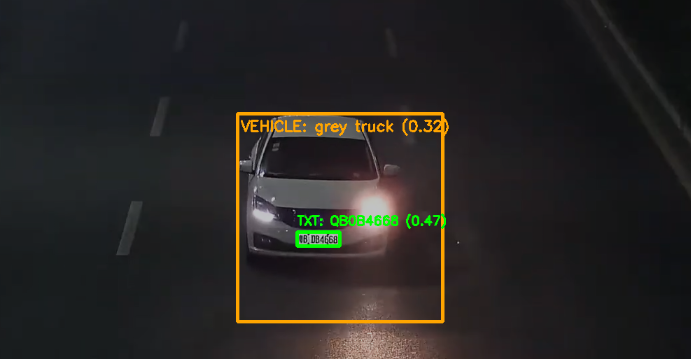

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import numpy as np
import torch
import os
from ultralytics import YOLO
import easyocr
from google.colab import files



DETECT_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/YOLO_Models/train_run_A100/weights/best.pt"
COLOR_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/YOLO_Models/color_classifier_A100/weights/best.pt"

IMAGE_PATH = "/content/TEST.png"
OUTPUT_IMAGE = "debug_output.jpg"

DETECT_CONF = 0.10
OCR_CONF = 0.45

MIN_PLATE_LEN = 3
MIN_PLATE_H = 10
MIN_PLATE_W = 35

VEHICLE_CLASSES = {
    'bike',
    'bus',
    'car',
    'truck',
    'cng'
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_GPU = torch.cuda.is_available()



print("⏳ Loading models...")

detect_model = YOLO(DETECT_MODEL_PATH)
color_model = YOLO(COLOR_MODEL_PATH)

ocr_engine = easyocr.Reader(
    ['en'],
    gpu=USE_GPU
)

print("✅ Models loaded")



def normalize_plate(txt):

    txt = txt.replace(" ", "")
    txt = txt.replace("-", "")
    txt = txt.replace("_", "")

    return "".join(
        c for c in txt if c.isalnum()
    ).upper()


def valid_plate(txt):

    if len(txt) < MIN_PLATE_LEN:
        return False

    alnum_count = sum(
        c.isalnum()
        for c in txt
    )

    return alnum_count >= 2


def preprocess_plate(crop):

    if crop is None:
        return None

    if crop.size == 0:
        return None

    h, w = crop.shape[:2]

    if h < MIN_PLATE_H or w < MIN_PLATE_W:
        return None

    scale = 128 / h

    crop = cv2.resize(
        crop,
        None,
        fx=scale,
        fy=scale,
        interpolation=cv2.INTER_LANCZOS4
    )

    crop = cv2.copyMakeBorder(
        crop,
        15,
        15,
        15,
        15,
        cv2.BORDER_CONSTANT,
        value=[255,255,255]
    )

    gray = cv2.cvtColor(
        crop,
        cv2.COLOR_BGR2GRAY
    )

    denoise = cv2.fastNlMeansDenoising(
        gray,
        h=10
    )

    clahe = cv2.createCLAHE(
        clipLimit=3,
        tileGridSize=(4,4)
    )

    enhanced = clahe.apply(
        denoise
    )

    sharpen_kernel = np.array([
        [0,-1,0],
        [-1,5,-1],
        [0,-1,0]
    ])

    sharp = cv2.filter2D(
        enhanced,
        -1,
        sharpen_kernel
    )

    _, binary = cv2.threshold(
        sharp,
        0,
        255,
        cv2.THRESH_BINARY+cv2.THRESH_OTSU
    )

    return [

        crop,

        cv2.cvtColor(
            enhanced,
            cv2.COLOR_GRAY2BGR
        ),

        cv2.cvtColor(
            binary,
            cv2.COLOR_GRAY2BGR
        )
    ]


def run_ocr(crop):

    versions = preprocess_plate(crop)

    if versions is None:
        return "No Plate",0,"Failed"

    names = [
        "Upscaled",
        "Enhanced",
        "Binarized"
    ]

    best_txt = "No Plate"
    best_conf = 0
    best_filter = "None"

    for idx,img in enumerate(versions):

        try:

            result = ocr_engine.readtext(
                img
            )

            if len(result)==0:
                continue

            txts = [
                x[1]
                for x in result
            ]

            confs = [
                x[2]
                for x in result
            ]

            combined = "".join(
                txts
            )

            norm = normalize_plate(
                combined
            )

            avg_conf = np.mean(
                confs
            )

            if valid_plate(norm):

                if avg_conf > best_conf:

                    best_conf = avg_conf
                    best_txt = norm
                    best_filter = names[idx]

        except:
            continue

    return best_txt,best_conf,best_filter




if not os.path.exists(IMAGE_PATH):

    raise FileNotFoundError(
        IMAGE_PATH
    )

frame = cv2.imread(
    IMAGE_PATH
)

debug = frame.copy()

h,w = frame.shape[:2]

print(
    f"\n📸 Processing: {w}x{h}"
)


results = detect_model(
    frame,
    conf=DETECT_CONF,
    imgsz=1920,
    verbose=False
)[0]

vehicles=[]
plates=[]

print("\n----- RAW DETECTIONS -----")

if results.boxes is not None:

    for box in results.boxes:

        cls_id = int(
            box.cls[0]
        )

        conf = float(
            box.conf[0]
        )

        cls_name = detect_model.names[
            cls_id
        ]

        x1,y1,x2,y2 = map(
            int,
            box.xyxy[0]
        )

        print(
            cls_name,
            f"{conf:.2f}"
        )

        cv2.rectangle(
            debug,
            (x1,y1),
            (x2,y2),
            (255,0,0),
            2
        )

        cv2.putText(
            debug,
            f"{cls_name}:{conf:.2f}",
            (x1,y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            .6,
            (255,0,0),
            2
        )

        if cls_name in VEHICLE_CLASSES:

            vehicles.append({

                "type":cls_name,
                "coords":(x1,y1,x2,y2)

            })

        elif cls_name=="License_Plate":

            plates.append({

                "coords":(x1,y1,x2,y2)

            })

print()
print(f"Vehicles: {len(vehicles)}")
print(f"Plates: {len(plates)}")




for i,p in enumerate(plates):

    px1,py1,px2,py2 = p["coords"]

    crop = frame[
        py1:py2,
        px1:px2
    ]

    plate_txt,ocr_conf,best_filter = run_ocr(
        crop
    )

    color=(0,255,0)

    if plate_txt=="No Plate":
        color=(0,0,255)

    cv2.rectangle(
        debug,
        (px1,py1),
        (px2,py2),
        color,
        3
    )

    cv2.putText(
        debug,
        f"{plate_txt} ({ocr_conf:.2f})",
        (px1,py1-5),
        cv2.FONT_HERSHEY_SIMPLEX,
        .6,
        color,
        2
    )

    print("\n===================")
    print("Plate:",i+1)
    print("Text:",plate_txt)
    print("Confidence:",round(ocr_conf,3))
    print("Filter:",best_filter)

    if ocr_conf>=OCR_CONF:
        print("Status: VALID")
    else:
        print("Status: LOW CONF")



for v in vehicles:

    x1,y1,x2,y2 = v["coords"]

    crop = frame[
        y1:y2,
        x1:x2
    ]

    if crop.size==0:
        continue

    try:

        result = color_model(
            crop,
            verbose=False
        )[0]

        color = color_model.names[
            result.probs.top1
        ]

    except:

        color="Unknown"

    cv2.putText(
        debug,
        f"{color} {v['type']}",
        (x1,y1+25),
        cv2.FONT_HERSHEY_SIMPLEX,
        .7,
        (0,165,255),
        2
    )



cv2.imwrite(
    OUTPUT_IMAGE,
    debug
)

print(
    f"\n💾 Saved: {OUTPUT_IMAGE}"
)

try:

    from google.colab.patches import cv2_imshow

    cv2_imshow(
        cv2.resize(
            debug,
            None,
            fx=.7,
            fy=.7
        )
    )

    files.download(
        OUTPUT_IMAGE
    )

except:

    cv2.imshow(
        "Debug",
        debug
    )

    cv2.waitKey(0)
    cv2.destroyAllWindows()